# TP1: Escalamiento
# Materia: Aprendizaje automatico

# Alumno: Moises Lobayza

# Actividad práctica: comparación de métodos de escalamiento en Scikit-learn
Objetivo
Comprender el impacto de diferentes técnicas de transformación y escalamiento de características utilizando el conjunto de datos de viviendas de California (California Housing dataset).

# Instrucciones
**Replicación del código:** Deben crear un notebook (en Colab, Jupyter o Kaggle) y replicar el código del tutorial oficial: Compare the effect of different scalers on data with outliers.

**Documentación en español:** Por cada sección de código que implemente un nuevo scaler, deben agregar una celda de texto explicando en sus propias palabras:

¿Qué hace matemáticamente el transformador?

¿Cómo trata los valores atípicos (outliers)?

**Análisis y cuestionario:** Al final del notebook, deben responder a las preguntas de reflexión detalladas en el siguiente cuestionario

# Cuestionario
1. Sensibilidad a los valores atípicos
Observa las gráficas de StandardScaler y MinMaxScaler. ¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?

2. Robustez
Compara el RobustScaler con el StandardScaler. Explica por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?

3. Normalización de la distribución
El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.

¿Qué diferencias visuales notas entre ellos?

¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

4. El caso del Normalizer
El Normalizer muestra un gráfico muy distinto a todos los demás (con una forma circular o arqueada).

¿Por qué este escalador actúa sobre las filas (muestras) en lugar de las columnas (características)?

Investiga un caso de uso (como procesamiento de texto o química) donde este comportamiento sea deseable.

5. Conclusión técnica
Si estuvieras entrenando un modelo de regresión lineal para predecir el precio de las casas y notas que la variable "ingreso medio" tiene muchos valores atípicos, ¿cuál de todos los métodos probados elegirías y por qué?

# Importamos librerias necesarias para el analisis.

numpy: manejar arrays numéricos.
matplotlib.pyplot as plt: hacer gráficos.

In [1]:
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt


#  Dataset y preprocessors

Con fetch_california_housing: trae el dataset.

Tambien se importan todos los **scalers/transformadores que vamos a comparar**.

minmax_scale: una función rápida para escalar entre 0 y 1.

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

dataset = fetch_california_housing()

# Cargar el dataset

dataset = fetch_california_housing() descarga/carga el dataset.

dataset.data = variables **predictoras**, o sea las **X**.

dataset.target = variable **objetivo**, o sea la **y**.

dataset.feature_names = nombres de las columnas.

In [3]:
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

Creamos una especie de “traductor” de nombres cortos a nombres más descriptivos. Aporta claridad

In [4]:
feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

Acá elegimos solo 2 columnas para visualizar.
La columna MedInc tiene una distribución de colar larga y la columna AveOccup tiene algunos valores atípicos que son muy grandes.

In [5]:
# Take only 2 features to make visualization easier
# Feature MedInc has a long tail distribution.
# Feature AveOccup has a few but very large outliers.
features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]

# Creamos todas las versiones transformadas.

Armamos una **lista de tuplas**, con titulo y datos transformados.
La lista tiene todos los metodos de escalado que vamos a ver.

# Un pequeño resumen de los métodos, luego se explayará en cada uno:

**StandardScaler**: centra en 0 y escala con desvío estándar, pero es sensible a outliers.

**MinMaxScaler**: lleva los valores al rango [0,1], pero los outliers comprimen al resto.

**MaxAbsScaler**: divide por el valor absoluto máximo y en datos positivos se parece a MinMaxScaler.

**RobustScaler**: usa mediana e IQR, por eso resiste mucho mejor los outliers.

**PowerTransformer**: transforma de forma no lineal para reducir asimetría y acercar la distribución a una normal.

**QuantileTransformer (uniform)**: reordena por cuantiles y fuerza una distribución uniforme entre 0 y 1.

**QuantileTransformer (normal)**: reordena por cuantiles y fuerza una distribución parecida a una normal.

**Normalizer**: normaliza cada fila para que tenga norma 1, no cada columna.

In [6]:
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

# Escalamos la variable objetivo para colores (visualizacion) y luego elegimos el mapa de color.

Toma y_full y la lleva al rango 0 a 1, se hace para colorear los puntos del grafico.
Elegimos la paleta de colores plasma, si no existe se elige hot_r.

In [7]:
y = minmax_scale(y_full)
cmap = getattr(cm, "plasma_r", cm.hot_r)

# **Funciones para la visualizacion.**

La función **create_axes** organiza la figura completa del gráfico. Primero crea la ventana principal y le asigna un título. Luego define manualmente la posición de cada parte del gráfico: el diagrama de dispersión completo, sus histogramas marginales, el gráfico con zoom con sus histogramas y la barra de color. Finalmente, devuelve todos esos ejes ya preparados para que después otra función dibuje los datos en cada uno.

In [8]:

def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # define the axis for the zoomed-in plot
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )

La función **plot_distribution** se encarga de dibujar los datos en los ejes creados previamente. Primero coloca el título y los nombres de los ejes. Luego genera el gráfico de dispersión usando las dos variables seleccionadas y colorea los puntos según el valor de y. Después ajusta detalles estéticos del gráfico para que se vea más claro. Finalmente, dibuja los histogramas marginales: uno arriba para la variable del eje X y otro al costado para la variable del eje Y, mostrando cómo se distribuye cada una por separado.

In [9]:

def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")

La función **make_plot** toma uno de los métodos guardados en la lista distributions y genera su gráfico completo. Primero obtiene el título y los datos transformados correspondientes a ese método. Luego crea los ejes del gráfico usando create_axes. Después dibuja la distribución completa de los datos con plot_distribution. A continuación, calcula un filtro para excluir los valores más extremos y así poder hacer un segundo gráfico con zoom sobre la masa principal de los datos. Finalmente, agrega la barra de color que relaciona los colores de los puntos con los valores de la variable objetivo y.

In [10]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

# **Vamos con los gráficos**

Se mostrarán dos gráficos para cada scaler/normalizer/transformer.
La figura de la izquierda mostrará un gráfico de dispersión de todo el dataset, mientras que la figura de la derecha excluirá los valores extremos y considerará solo el 99 % de los datos, dejando afuera los outliers marginales. Además, en los costados del gráfico de dispersión se mostrarán las distribuciones marginales de cada variable.

# **Datos originales**

Este gráfico muestra los datos originales, sin aplicar ningún método de escalado. A la izquierda se observa el conjunto completo y se nota que existen outliers muy grandes, especialmente en AveOccup, lo que aplasta visualmente a la mayoría de los puntos cerca del eje inferior. A la derecha se hace un zoom quitando los valores más extremos, lo que permite ver mejor la masa principal de los datos. Los histogramas grises muestran la distribución de cada variable por separado y permiten notar la concentración de la mayoría de los valores y la presencia de colas largas.

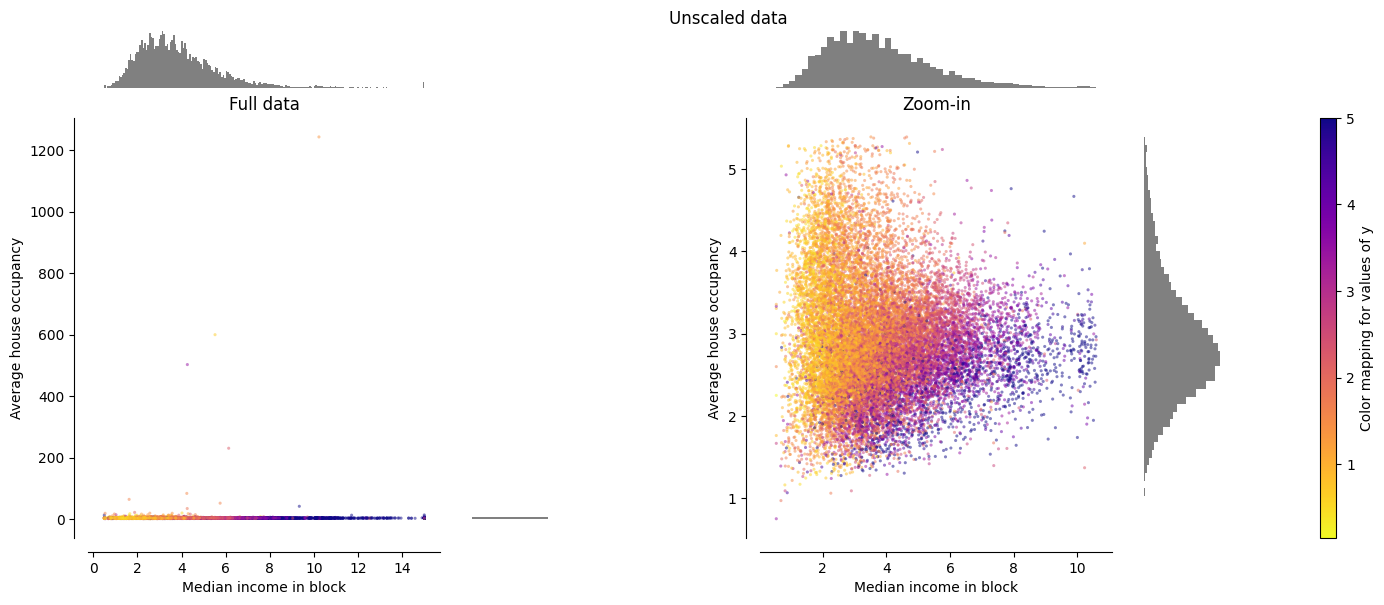

In [11]:
make_plot(0)

# **StandardScaler**

**¿Qué hace matemáticamente?**
StandardScaler transforma cada variable restándole su media y dividiéndola por su desvío estándar, de modo que quede centrada en 0 y con varianza cercana a 1.

**¿Cómo trata los outliers?**
Los outliers lo afectan bastante, porque tanto la media como el desvío estándar son sensibles a valores extremos. Por eso, si hay datos muy alejados, la mayor parte de los valores normales puede quedar comprimida.

**Mini lectura del gráfico**
En el gráfico se observa que la forma general se mantiene, pero AveOccup queda mucho más comprimida que MedInc, mostrando que este método no maneja bien los outliers.

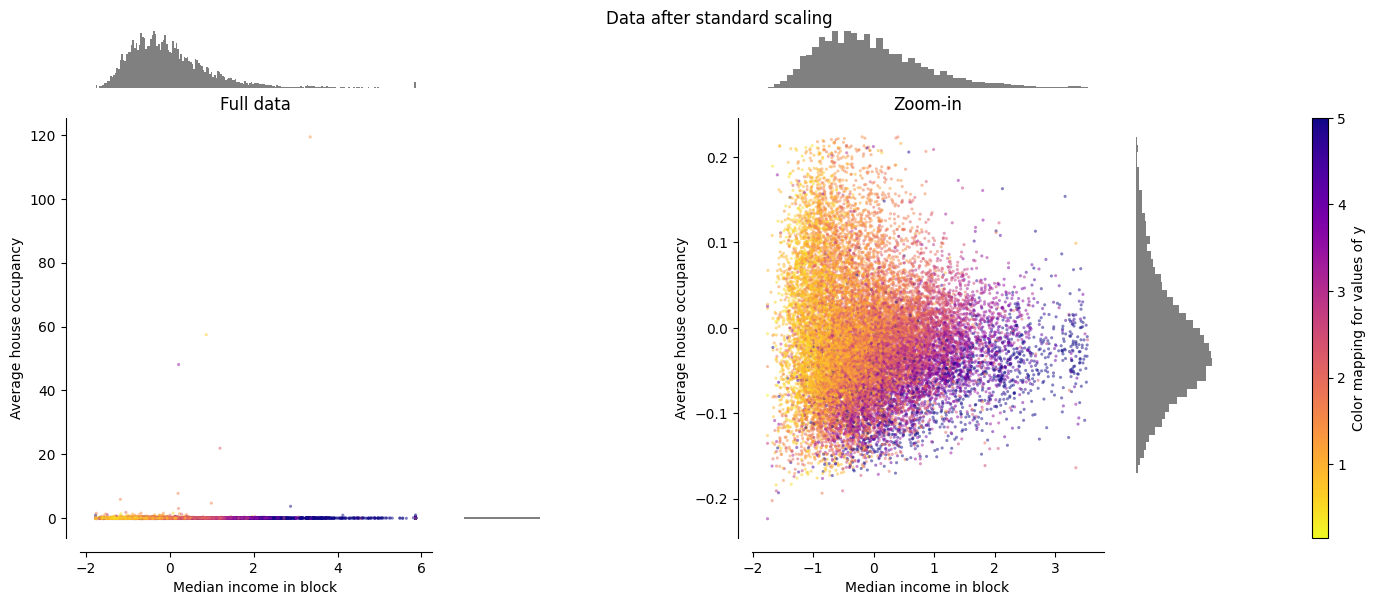

In [12]:
make_plot(1)

# **MinMaxScaler**

**¿Qué hace matemáticamente?**
MinMaxScaler transforma cada variable usando su valor mínimo y su valor máximo, de manera que todos los datos queden dentro del rango [0,1].

**¿Cómo trata los outliers?**
Los outliers lo afectan mucho, porque si un valor extremo fija el máximo o el mínimo, la mayor parte de los datos normales queda comprimida en una franja muy pequeña.

**Mini lectura del gráfico**
En el gráfico se ve que ambas variables quedan entre 0 y 1, pero AveOccup queda muy aplastada cerca de 0 en la vista con zoom. Esto muestra que, aunque el rango es prolijo, el método no maneja bien los valores atípicos.

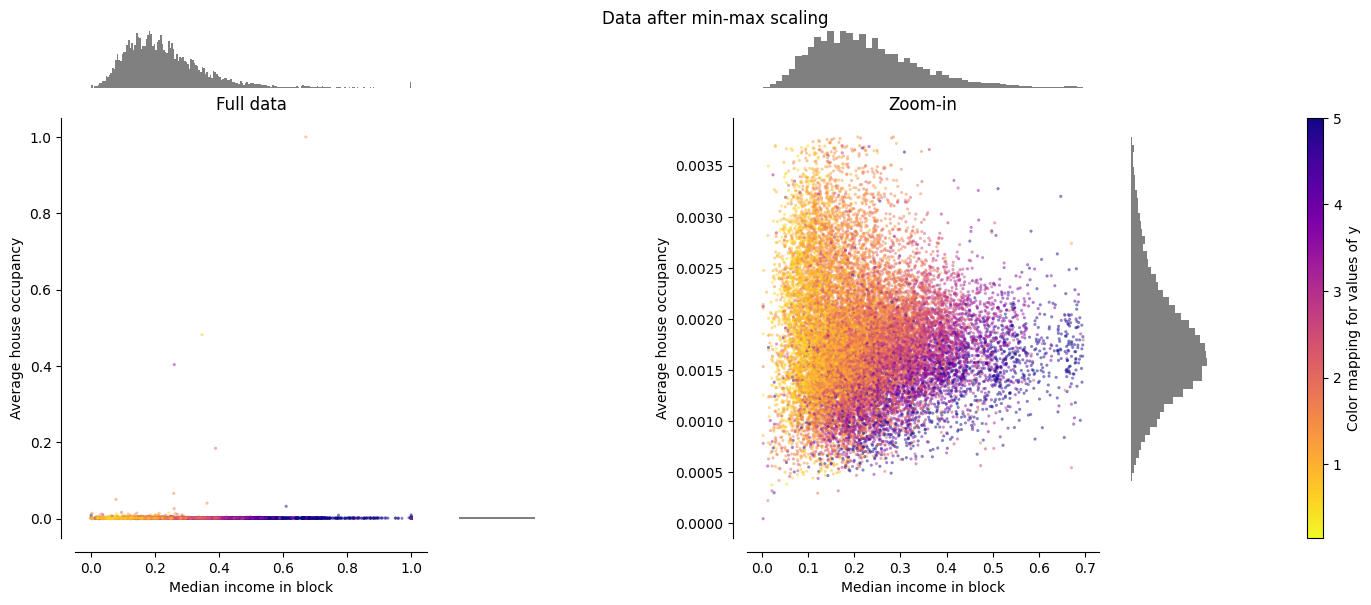

In [13]:
make_plot(2)

# **MaxAbsScaler**

**¿Qué hace matemáticamente?**
MaxAbsScaler divide cada valor por el valor absoluto máximo de su variable, de modo que los datos queden acotados entre -1 y 1 o, si todos son positivos, entre 0 y 1.

**¿Cómo trata los outliers?**
Los outliers también lo afectan bastante, porque un valor extremo pasa a definir el máximo absoluto y hace que el resto de los datos quede comprimido.

**Mini lectura del gráfico**
En este caso el resultado es muy parecido al de MinMaxScaler, porque las variables analizadas son positivas. En la vista con zoom se nota otra vez que AveOccup queda muy comprimida, así que este método tampoco resulta robusto frente a valores atípicos.

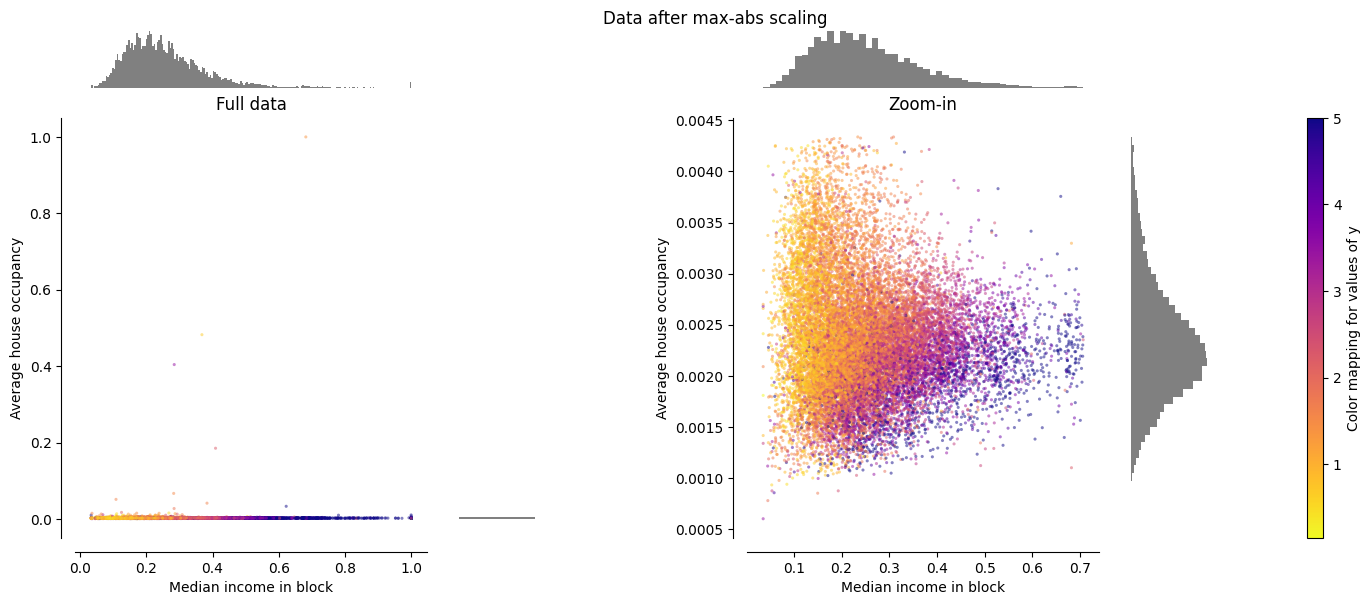

In [14]:
make_plot(3)

# **RobustScaler**

**¿Qué hace matemáticamente?**
RobustScaler centra cada variable usando la mediana y la escala usando el rango intercuartílico (IQR), es decir, la diferencia entre el percentil 75 y el 25.

**¿Cómo trata los outliers?**
**Los outliers influyen mucho menos** que en los métodos anteriores, porque la mediana y los percentiles son estadísticas más robustas frente a valores extremos. Sin embargo, los outliers no desaparecen: siguen presentes en los datos transformados.

**Mini lectura del gráfico**
En la vista con zoom se observa que la masa principal de los datos queda mucho mejor distribuida y que ambas variables tienen escalas más parecidas. Esto muestra que RobustScaler maneja mucho mejor la presencia de outliers que StandardScaler, MinMaxScaler y MaxAbsScaler.

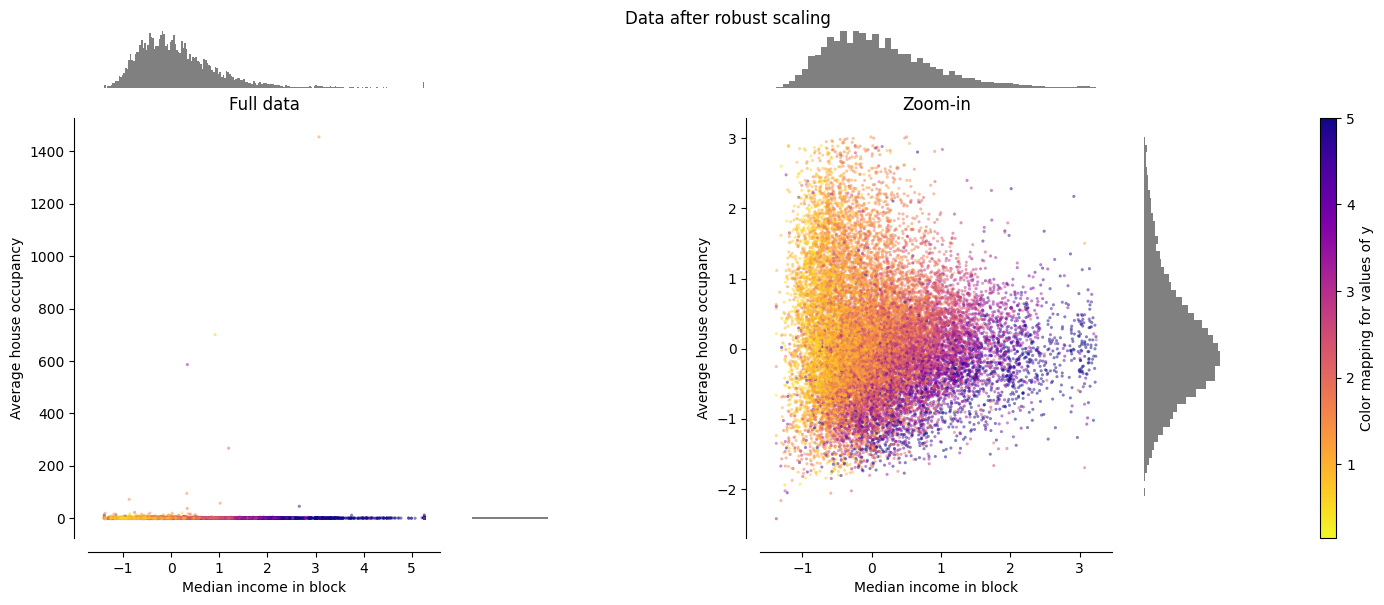

In [15]:
make_plot(4)

# **PowerTransformer**

**¿Qué hace matemáticamente?**
PowerTransformer aplica una transformación no lineal a cada variable para reducir la asimetría, estabilizar la varianza y hacer que la distribución se parezca más a una normal. En este ejemplo se prueban dos variantes: **Yeo-Johnson** y **Box-Cox**.

**¿Cómo trata los outliers?**
No elimina los outliers, pero al modificar la forma de la distribución reduce bastante su impacto sobre la escala y sobre la asimetría de los datos. Box-Cox solo puede usarse con datos estrictamente positivos, mientras que Yeo-Johnson también sirve si hubiera valores negativos.

**Mini lectura del gráfico**
En ambos gráficos se observa una nube más equilibrada y distribuciones más cercanas a una forma normal. Los resultados de Yeo-Johnson y Box-Cox son bastante parecidos en este dataset porque las variables analizadas son positivas, por lo que ambas transformaciones pueden aplicarse sin problema.

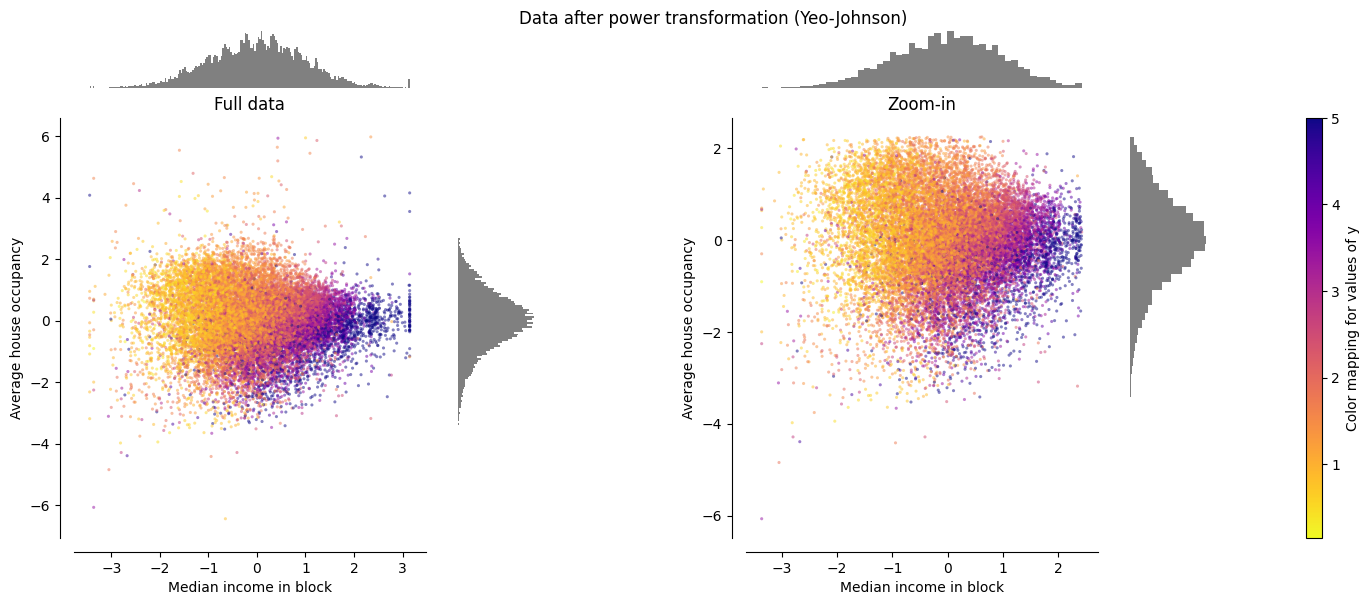

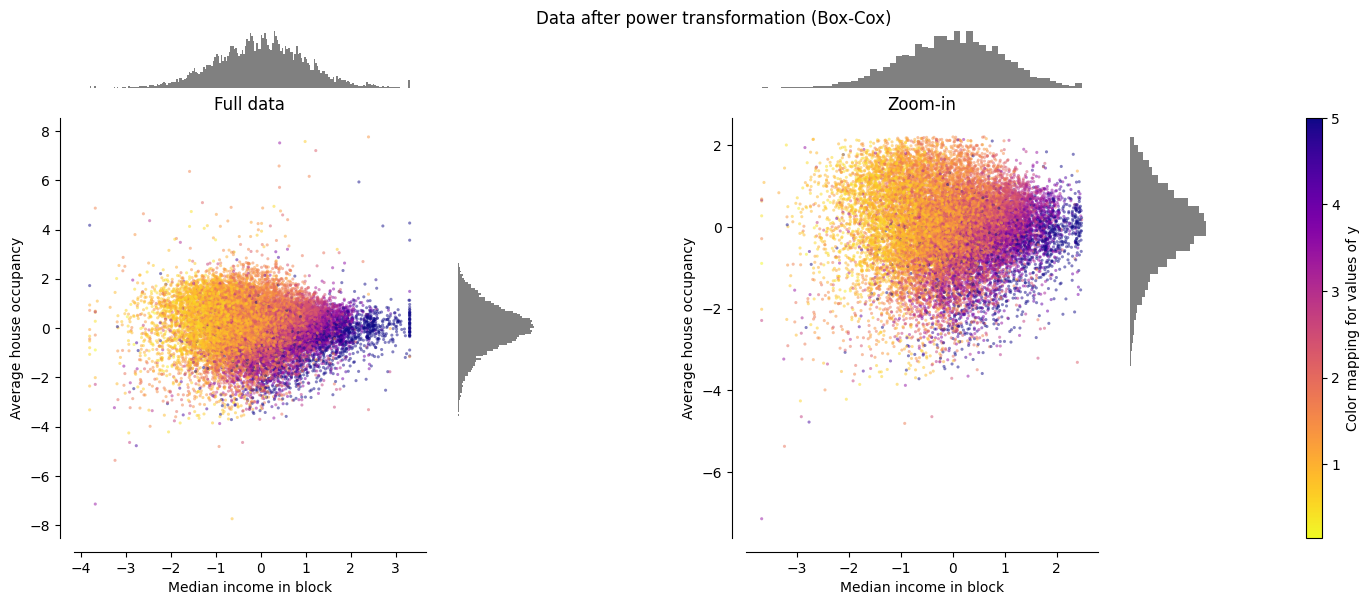

In [16]:
make_plot(5)
make_plot(6)

# **QuantileTransformer (uniform output)**

**¿Qué hace matemáticamente?**
QuantileTransformer transforma cada variable según sus cuantiles, es decir, según la posición relativa de cada valor dentro de la distribución. En esta versión, fuerza a que la salida tenga una distribución uniforme en el rango [0,1].

**¿Cómo trata los outliers?**
Es bastante robusto frente a outliers, porque no depende tanto de su magnitud exacta sino de su orden relativo. Además, comprime los valores extremos y los lleva a los bordes del rango, por lo que los outliers dejan de dominar la escala, aunque también se pierde información sobre cuán extremos eran.

**Mini lectura del gráfico**
En el gráfico la nube toma una forma casi cuadrada y los histogramas se ven bastante planos, lo que indica que ambas variables fueron redistribuidas de manera uniforme entre 0 y 1. También se nota que el gráfico completo y el zoom se parecen mucho más, porque los outliers ya no estiran los ejes como en los métodos lineales.

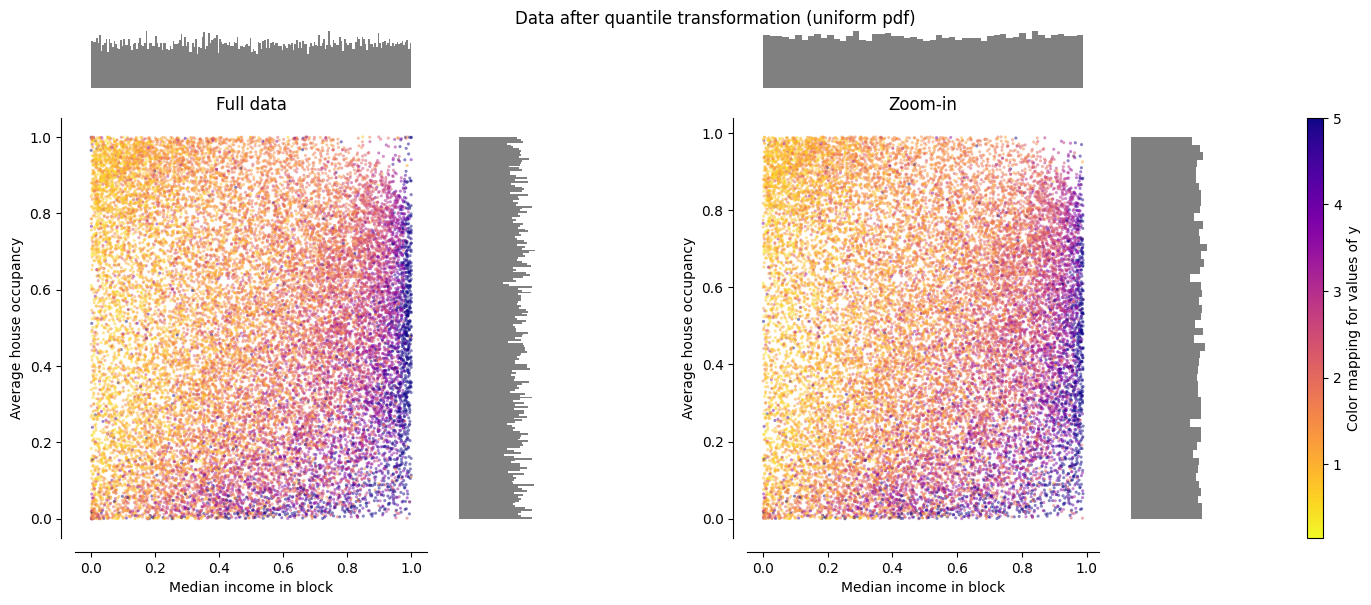

In [17]:
make_plot(7)

# **QuantileTransformer (Gaussian output)**

**¿Qué hace matemáticamente?**
QuantileTransformer vuelve a transformar cada variable según sus cuantiles, pero en este caso fuerza a que la salida tenga una distribución parecida a una normal o gaussiana, en lugar de uniforme.

**¿Cómo trata los outliers?**
También es robusto frente a outliers, ya que no depende tanto del valor exacto de los extremos sino de su posición relativa. Los valores muy extremos quedan comprimidos en las colas de la distribución normal, por lo que dejan de dominar la escala, aunque se pierde detalle sobre qué tan extremos eran entre sí.

**Mini lectura del gráfico**
En este gráfico los histogramas ya no son planos, sino que toman una forma más parecida a una campana, lo que muestra que las variables fueron llevadas hacia una distribución normal. La nube queda más concentrada en la zona central y los outliers ya no deforman tanto la visualización como en los métodos lineales.

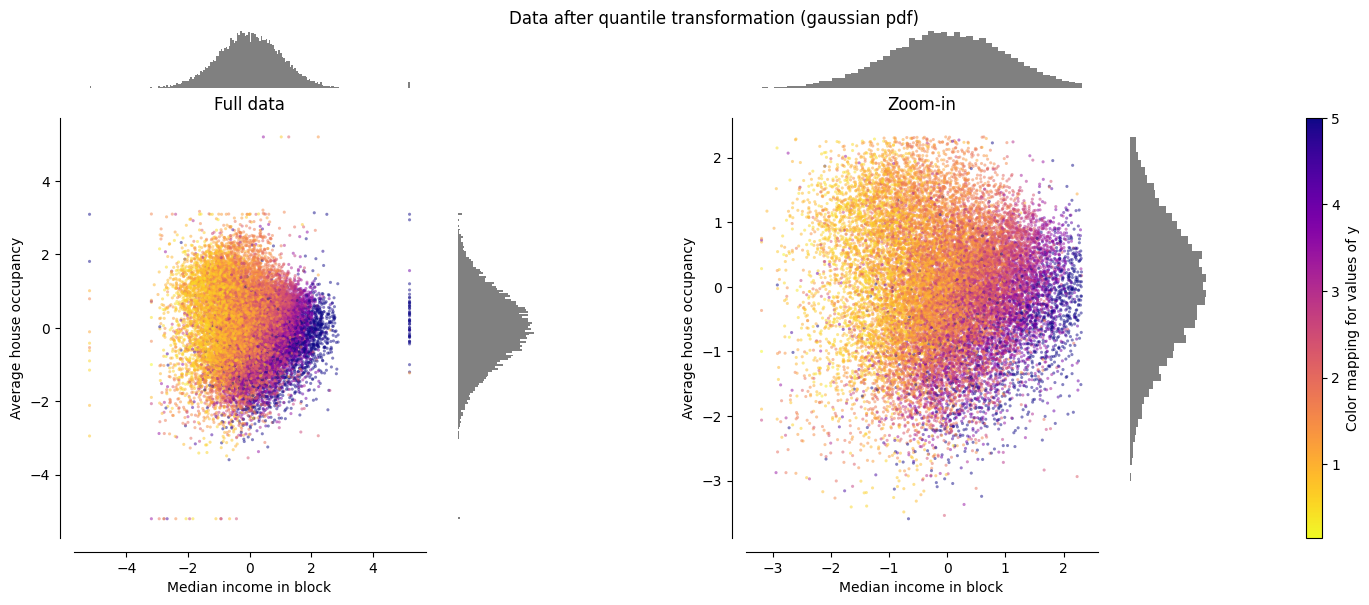

In [18]:
make_plot(8)

# **Normalizer**

**¿Qué hace matemáticamente?**
Normalizer transforma cada muestra completa para que su norma sea 1. Es decir, no trabaja por columnas como los otros métodos, sino por filas, reescalando cada vector según su longitud total.

**¿Cómo trata los outliers?**
No está pensado específicamente para corregir outliers en una variable, porque no compara valores dentro de cada columna. Lo que hace es cambiar cada observación según su propia magnitud, por lo que el efecto de los outliers se interpreta distinto al de los otros scalers.

**Mini lectura del gráfico**
En el gráfico los puntos forman un arco porque, al normalizar cada muestra a norma 1, todas las observaciones quedan sobre el círculo unitario. Como las dos variables son positivas, los puntos aparecen solo en el cuadrante positivo. Este resultado es muy diferente al de los otros métodos porque aquí se conserva más la proporción entre variables dentro de cada fila que su escala original.

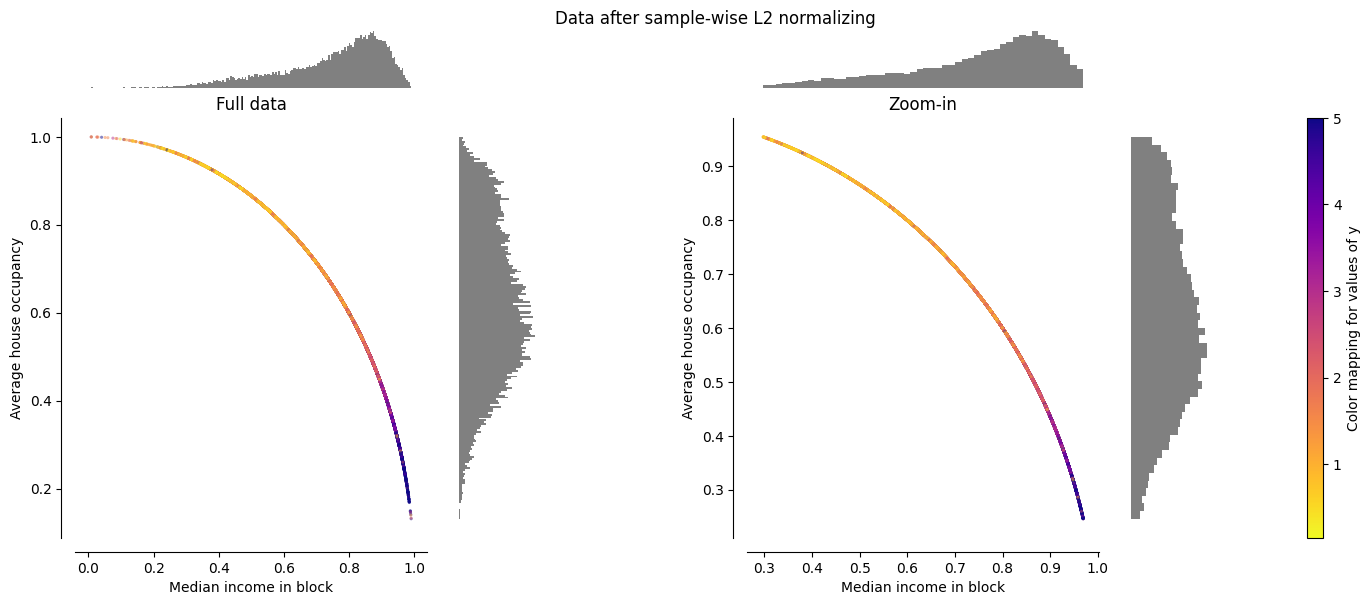

In [19]:
make_plot(9)

plt.show()

## Análisis y cuestionario:

**1. Sensibilidad a los valores atípicos**

Observa las gráficas de StandardScaler y MinMaxScaler. ¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?

**Respuesta:** En StandardScaler y MinMaxScaler, los valores atípicos muy alejados hacen que la masa principal de los datos quede comprimida en una zona pequeña del gráfico, por lo que se pierde visibilidad sobre la estructura real de la mayoría de las observaciones. Esto ocurre porque ambos métodos utilizan estadísticas sensibles a los valores extremos: StandardScaler depende de la media y la desviación estándar, mientras que MinMaxScaler depende directamente del valor mínimo y máximo. Por eso, estos escaladores pueden resultar problemáticos cuando existen outliers muy grandes.

**2. Robustez**
Compara el RobustScaler con el StandardScaler. Explica por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?

**Respuesta:** RobustScaler mantiene mejor el “zoom” sobre la mayoría de los datos porque reduce mucho la influencia de los valores atípicos en la transformación. A diferencia de StandardScaler, que utiliza la media y la desviación estándar y por eso se ve muy afectado por los extremos, RobustScaler usa la mediana para centrar los datos y el rango intercuartílico (IQR, diferencia entre el percentil 75 y el 25) para escalarlos. Como estos estadísticos son más resistentes a los outliers, la masa principal de los datos conserva mejor su dispersión, aunque los valores extremos sigan apareciendo en los ejes.

**3. Normalización de la distribución**
El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.

¿Qué diferencias visuales notas entre ellos?

¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

**Respuesta:** Tanto PowerTransformer (Yeo-Johnson) como QuantileTransformer con salida gaussiana buscan aproximar los datos a una distribución normal, pero lo hacen de manera distinta. Visualmente, PowerTransformer produce una transformación más suave y conserva mejor la forma original de los datos, mientras que QuantileTransformer fuerza de manera más marcada la distribución hacia una forma gaussiana, comprimiendo más los valores extremos. Estas transformaciones pueden ser más útiles que un simple escalado lineal en modelos sensibles a la escala, a la distancia y a la forma de la distribución, como la regresión lineal, la regresión logística, SVM o KNN, ya que ayudan a reducir la asimetría y el efecto de los outliers.

**4. El caso del Normalizer**

El Normalizer muestra un gráfico muy distinto a todos los demás (con una forma circular o arqueada).

¿Por qué este escalador actúa sobre las filas (muestras) en lugar de las columnas (características)?

Investiga un caso de uso (como procesamiento de texto o química) donde este comportamiento sea deseable.

**Respuesta:** Normalizer actúa sobre las filas porque transforma cada muestra completa como un vector y no cada característica por separado. Su objetivo es que cada observación tenga norma 1, por lo que pasa a importar más la relación interna entre sus valores que su magnitud total. Por eso el gráfico resultante tiene una forma tan distinta a la de los otros métodos. Este comportamiento es útil cuando interesa más la dirección o proporción del vector que su tamaño absoluto, como ocurre en procesamiento de texto con matrices TF-IDF, donde se comparan documentos por su contenido relativo y no por su longitud, o en química/espectroscopía, donde puede importar más la forma de la señal que su intensidad total.

**5. Conclusión técnica**

Si estuvieras entrenando un modelo de regresión lineal para predecir el precio de las casas y notas que la variable "ingreso medio" tiene muchos valores atípicos, ¿cuál de todos los métodos probados elegirías y por qué?

**Respuesta:** Si estuviera entrenando un modelo de regresión lineal y notara que la variable ingreso medio tiene muchos valores atípicos, elegiría RobustScaler. La razón es que este método utiliza la mediana y el rango intercuartílico en lugar de la media y la desviación estándar, por lo que es mucho menos sensible a los outliers. De este modo, la mayor parte de los datos conserva mejor su escala real y no queda tan comprimida como ocurre con StandardScaler o MinMaxScaler. Aunque métodos como PowerTransformer o QuantileTransformer también podrían ser útiles, RobustScaler resulta una opción más equilibrada cuando el principal problema es la presencia de valores extremos.

# **Conclusión:**
 El propósito de este trabajo fue analizar cómo distintos métodos de escalamiento y transformación modifican los datos y cómo reaccionan frente a la presencia de valores atípicos. A lo largo de la comparación se observó que algunos métodos, como StandardScaler y MinMaxScaler, son muy sensibles a los outliers, mientras que otros, como RobustScaler, logran conservar mejor la estructura de la masa principal de los datos. También se vio que métodos como PowerTransformer y QuantileTransformer no solo cambian la escala, sino también la forma de la distribución. En definitiva, el trabajo permitió comprender que el preprocesamiento es una etapa clave en machine learning, ya que la elección del método adecuado puede influir mucho en cómo se representan los datos y en el desempeño posterior de los modelos.